# SynthACticBench O6 Multimodal — depth policies

Five fixed depths, staged `3 → 6 → 9 → 20`, and reproducible random rotation among `{3, 9, 20}`.

In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "01_initial":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o6_multi_modal/depth_policies/01_initial")
OUTPUT_DIRECTORY = HERE / "smac_output"
DEPTHS = (3, 6, 9, 15, 20)
FIXED = tuple(f"fixed_depth_{d}" for d in DEPTHS)
STAGED = "staged_depth_3_6_9_20"
RANDOM = "random_depth_3_9_20_every_50"
INCREMENTS = (1, 2, 3, 4)
INCREMENTING = tuple(f"increment_depth_by_{increment}_every_100" for increment in INCREMENTS)
POLICIES = FIXED + (STAGED, RANDOM) + INCREMENTING
SEEDS = tuple(range(5))
N_TRIALS = 1000
CHECKPOINTS = tuple(range(100, 1001, 100))
LABELS = {f"fixed_depth_{d}": f"depth = {d}" for d in DEPTHS}
LABELS.update({STAGED: "staged 3 → 6 → 9 → 20", RANDOM: "random {3, 9, 20} / 50"})
LABELS.update({policy: f"depth +{increment} / 100" for policy, increment in zip(INCREMENTING, INCREMENTS)})
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4", "black", "C6", "tab:olive", "tab:cyan", "tab:pink", "tab:brown")))

In [3]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        seed = result["smac_seed"]
        if seed in SEEDS and result["n_trials"] == N_TRIALS:
            runs[seed] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing completed runs for {policy}: seeds={missing}")
    return runs

results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    for result in runs.values():
        assert result["problem"] == "O6-Multimodal"
        assert result["problem_seed"] == 52
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert len(result["best_regret"]) == N_TRIALS
        if policy in FIXED:
            assert result["max_depth"] == int(policy.rsplit("_", 1)[1])
        elif policy == STAGED:
            assert result["stage_boundaries"] == [100, 200, 500]
            assert result["depth_schedule"] == [3, 6, 9, 20]
        elif policy == RANDOM:
            assert result["block_size"] == 50
            assert result["depth_choices"] == [3, 9, 20]
        else:
            assert result["depth_policy"] == "linear_increment"
            assert result["initial_depth"] == 3
            assert result["block_size"] == 100
            assert result["depth_increment"] == int(policy.split("_")[3])
print(f"Loaded {sum(map(len, results.values()))}/55 validated trajectories.")

Loaded 55/55 validated trajectories.


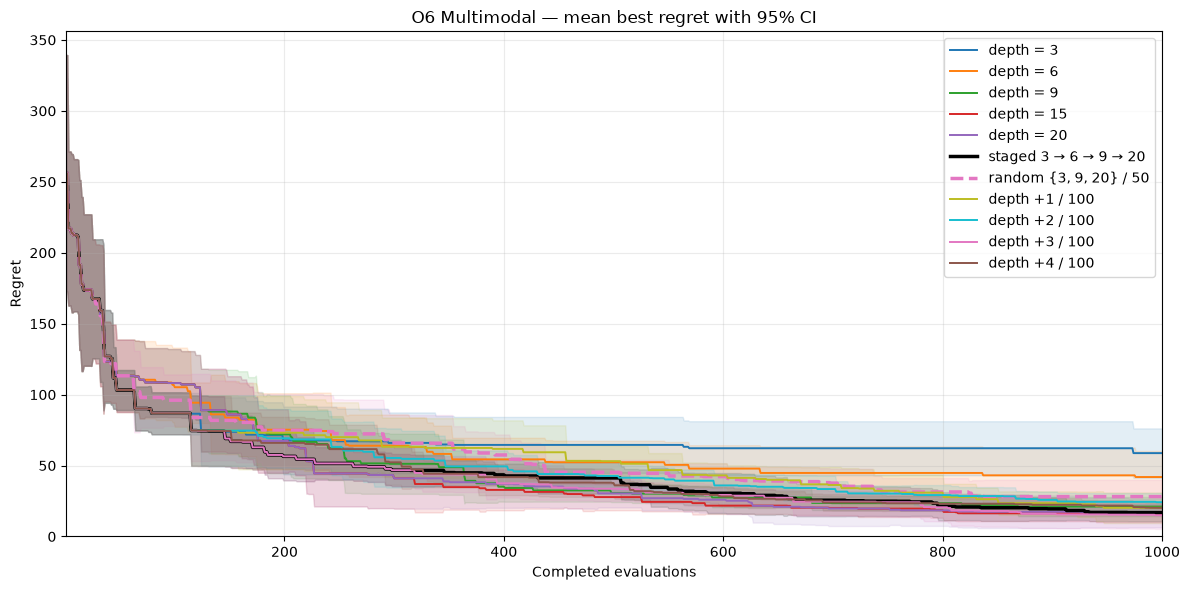

In [4]:
rows = [
    {"policy": policy, "seed": seed, "iteration": i, "best_regret": regret}
    for policy, runs in results.items() for seed, result in runs.items()
    for i, regret in zip(result["iteration"], result["best_regret"])
]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(12, 6))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    width = 2.5 if policy in (STAGED, RANDOM) else 1.4
    style = "--" if policy == RANDOM else "-"
    ax.plot(data.iteration, data["mean"], label=LABELS[policy], color=COLORS[policy], linewidth=width, linestyle=style)
    ax.fill_between(data.iteration, np.maximum(0, data["mean"] - data.ci95), data["mean"] + data.ci95, color=COLORS[policy], alpha=.12)
ax.set(title="O6 Multimodal — mean best regret with 95% CI", xlabel="Completed evaluations", ylabel="Regret", xlim=(1, 1000), ylim=(0, None))
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

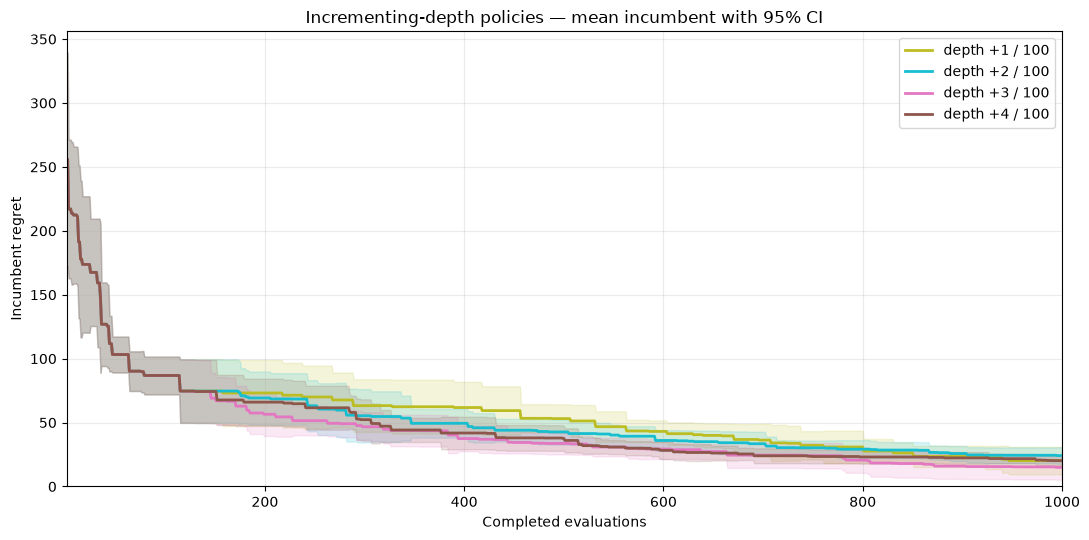

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for policy in INCREMENTING:
    data = summary[summary.policy == policy]
    ax.plot(
        data.iteration,
        data["mean"],
        label=LABELS[policy],
        color=COLORS[policy],
        linewidth=2,
    )
    ax.fill_between(
        data.iteration,
        np.maximum(0, data["mean"] - data.ci95),
        data["mean"] + data.ci95,
        color=COLORS[policy],
        alpha=0.16,
    )
ax.set(
    title="Incrementing-depth policies — mean incumbent with 95% CI",
    xlabel="Completed evaluations",
    ylabel="Incumbent regret",
    xlim=(1, N_TRIALS),
    ylim=(0, None),
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

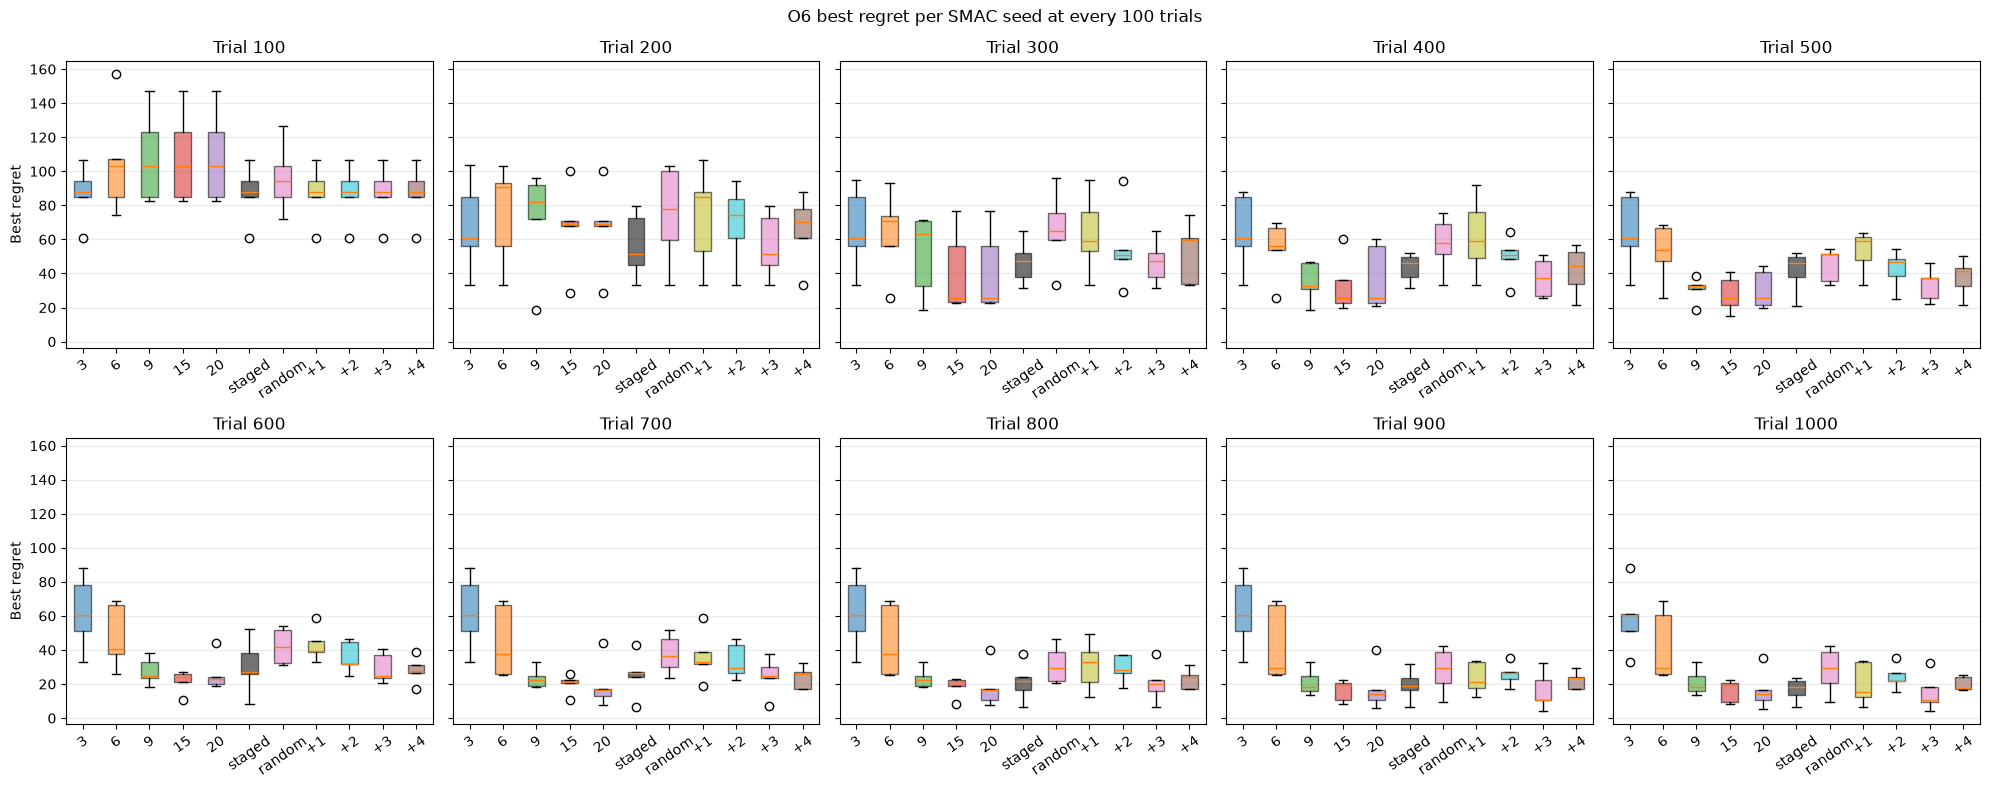

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[p][s]["best_regret"][checkpoint - 1] for s in SEEDS] for p in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(d) for d in DEPTHS] + ["staged", "random"] + [f"+{i}" for i in INCREMENTS])
    for box, policy in zip(boxes["boxes"], POLICIES): box.set(facecolor=COLORS[policy], alpha=.55)
    ax.set_title(f"Trial {checkpoint}"); ax.tick_params(axis="x", rotation=35); ax.grid(axis="y", alpha=.25)
for ax in axes[:, 0]: ax.set_ylabel("Best regret")
fig.suptitle("O6 best regret per SMAC seed at every 100 trials"); plt.tight_layout(); plt.show()

In [7]:
mean_regret = trajectories.pivot_table(index="iteration", columns="policy", values="best_regret", aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({p: np.isclose(mean_regret[p], best, rtol=1e-12, atol=1e-9) for p in POLICIES}, index=mean_regret.index)
block_rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum()
    maximum = int(counts.max())
    row = {"iterations": f"{end - 99}–{end}", "superior policy": ", ".join(LABELS[p] for p in POLICIES if counts[p] == maximum), "winning iterations": maximum}
    row.update({LABELS[p]: int(counts[p]) for p in POLICIES}); block_rows.append(row)
block_superiority = pd.DataFrame(block_rows)
block_superiority

,iterations,superior policy,winning iterations,depth = 3,depth = 6,depth = 9,depth = 15,depth = 20,staged 3 → 6 → 9 → 20,"random {3, 9, 20} / 50",depth +1 / 100,depth +2 / 100,depth +3 / 100,depth +4 / 100
0,1–100,"depth = 3, staged 3 → 6 → 9 → 20, depth +1 / 1...",83,83,43,43,43,43,83,44,83,83,83,83
1,101–200,"staged 3 → 6 → 9 → 20, depth +3 / 100",76,29,0,0,0,0,76,0,12,12,76,13
2,201–300,"depth = 15, depth = 20",81,0,0,0,81,81,19,0,0,0,19,0
3,301–400,depth = 15,100,0,0,0,100,18,0,0,0,0,0,0
4,401–500,depth = 15,100,0,0,0,100,0,0,0,0,0,0,0
5,501–600,depth = 15,100,0,0,0,100,0,0,0,0,0,0,0
6,601–700,depth = 15,60,0,0,0,60,40,0,0,0,0,0,0
7,701–800,depth = 20,71,0,0,0,29,71,0,0,0,0,0,0
8,801–900,depth = 15,71,0,0,0,71,0,0,0,0,0,29,0
9,901–1000,depth +3 / 100,100,0,0,0,0,0,0,0,0,0,100,0


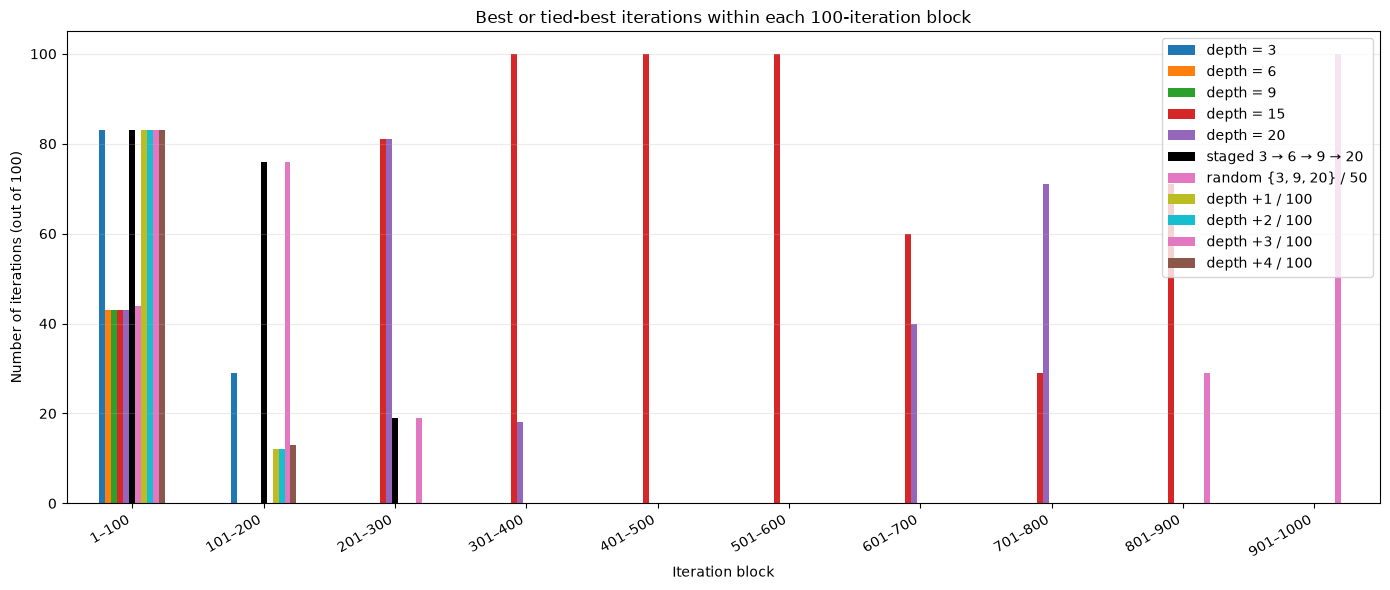

In [8]:
count_columns = [LABELS[policy] for policy in POLICIES]
ax = block_superiority.set_index("iterations")[count_columns].plot(
    kind="bar",
    figsize=(14, 6),
    color=[COLORS[policy] for policy in POLICIES],
)
ax.set(
    title="Best or tied-best iterations within each 100-iteration block",
    xlabel="Iteration block",
    ylabel="Number of iterations (out of 100)",
    ylim=(0, 105),
)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [9]:
checkpoint_statistics = (
    trajectories[trajectories.iteration.isin(CHECKPOINTS)]
    .groupby(["iteration", "policy"])["best_regret"]
    .agg(["mean", "std", "min", "median", "max"])
)
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
):
    display(checkpoint_statistics)

mean        std        min  \
iteration policy                                                             
100       fixed_depth_15                  108.159702  27.374557  82.534547   
          fixed_depth_20                  108.159702  27.374557  82.534547   
          fixed_depth_3                    86.838565  16.881626  60.659200   
          fixed_depth_6                   105.218143  31.865388  74.249163   
          fixed_depth_9                   108.159702  27.374557  82.534547   
          increment_depth_by_1_every_100   86.838565  16.881626  60.659200   
          increment_depth_by_2_every_100   86.838565  16.881626  60.659200   
          increment_depth_by_3_every_100   86.838565  16.881626  60.659200   
          increment_depth_by_4_every_100   86.838565  16.881626  60.659200   
          random_depth_3_9_20_every_50     96.075720  20.676057  71.793729   
          staged_depth_3_6_9_20            86.838565  16.881626  60.659200   
200       fixed_depth_15                   67.294187  25.525637  28.332721   
          fixed_depth_20                   67.294187  25.525637  28.332721   
          fixed_depth_3                    67.699861  27.244882  33.198932   
          fixed_depth_6                    75.263739  29.366625  33.198932   
          fixed_depth_9                    72.005173  31.316931  18.503960   
          increment_depth_by_1_every_100   73.150934  29.476898  33.198932   
          increment_depth_by_2_every_100   69.242755  23.609473  33.198932   
          increment_depth_by_3_every_100   56.499911  19.377571  33.198932   
          increment_depth_by_4_every_100   65.984780  20.919533  33.198932   
          random_depth_3_9_20_every_50     74.802405  29.219811  33.198932   
          staged_depth_3_6_9_20            56.499911  19.377571  33.198932   
300       fixed_depth_15                   41.006854  24.405855  22.895056   
          fixed_depth_20                   41.006854  24.405855  22.895056   
          fixed_depth_3                    65.960613  24.501347  33.198932   
          fixed_depth_6                    63.967635  25.028431  25.779734   
          fixed_depth_9                    51.233598  24.140201  18.503960   
          increment_depth_by_1_every_100   63.257686  23.462077  33.198932   
          increment_depth_by_2_every_100   55.347116  23.764296  29.273174   
          increment_depth_by_3_every_100   46.739703  12.988121  31.660035   
          increment_depth_by_4_every_100   52.281519  18.135143  33.198932   
          random_depth_3_9_20_every_50     65.931690  22.971373  33.198932   
          staged_depth_3_6_9_20            46.739703  12.988121  31.660035   
400       fixed_depth_15                   32.847807  16.412626  19.573027   
          fixed_depth_20                   37.113043  19.286737  20.755319   
          fixed_depth_3                    64.551263  22.526961  33.198932   
          fixed_depth_6                    54.377281  17.307090  25.779734   
          fixed_depth_9                    35.065219  11.954991  18.503960   
          increment_depth_by_1_every_100   61.761656  22.927373  33.198932   
          increment_depth_by_2_every_100   49.418214  12.813718  29.273174   
          increment_depth_by_3_every_100   37.479182  11.432834  25.800600   
          increment_depth_by_4_every_100   41.833245  14.485862  21.299967   
          random_depth_3_9_20_every_50     57.453439  16.477982  33.198932   
          staged_depth_3_6_9_20            43.437139   8.555551  31.660035   
500       fixed_depth_15                   27.789843  10.644259  14.962961   
          fixed_depth_20                   30.403302  11.370824  19.958644   
          fixed_depth_3                    64.551263  22.526961  33.198932   
          fixed_depth_6                    52.339714  17.308003  25.779734   
          fixed_depth_9                    30.736612   7.401696  18.503960   
          increment_depth_by_1_every_100   53.103007  12.744656  33.19